# Predictive performance across OpenML-CC18

**Hypothesis:** Recursive Sketch with one, two, or three iterations produces a distinguishable held-out accuracy relative to a standard random forest, and the difference is consistent across a multi-dataset OpenML-CC18 sample.

Each `(dataset_id, repetition_id)` pair is one paired block. For every downstream classifier, the analysis compares its raw-input baseline with Recursive Sketch at `T=1`, `T=2`, and `T=3` within every dataset/repetition block. The internal path estimator can be selected as either a random forest or a bootstrapped recursive partitioner. The default classifier set contains logistic regression, a random forest, and an RBF SVM with automatic feature scaling and the default regularization convention. The joint-block analysis is exploratory; a confirmatory analysis should also aggregate repetitions within each dataset so that repeated seeds do not artificially increase the apparent number of independent datasets.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import t
from sklearn.exceptions import DataDimensionalityWarning

warnings.filterwarnings('ignore', category=DataDimensionalityWarning)
warnings.filterwarnings(
    'ignore',
    message=r'`sklearn\.utils\.parallel\.delayed` should be used with',
    category=UserWarning,
    module=r'sklearn\.utils\.parallel',
)
warnings.filterwarnings(
    'ignore',
    message=r'The number of unique classes is greater than 50% of the number of samples',
    category=UserWarning,
    module=r'sklearn\.svm\._base',
)
# Propagate the narrow filter to loky/joblib worker processes.
os.environ['PYTHONWARNINGS'] = (
    'ignore:`sklearn.utils.parallel.delayed` should be used with:UserWarning,'
    'ignore:The number of unique classes is greater than 50% of the number of samples:UserWarning'
)

from _hypothesis_utils import (
    DEFAULT_DIMENSION_RATIO,
    DEFAULT_N_ESTIMATORS,
    classification_score,
    make_datasets,
    openml_classification_split,
    openml_output_classifier,
    recursive_sketch,
    plot_critical_difference,
    timed_fit_transform,
)

DATASET_COUNT = 4
MAX_DATASET_SIZE = 2000
DATASET_NAMES = None
# Example: DATASET_NAMES = ['kr-vs-kp', 'letter', 'balance-scale', 'mfeat-factors', 'mfeat-fourier']
DATASETS = make_datasets(
    n=None if DATASET_NAMES is not None else DATASET_COUNT,
    max_size=MAX_DATASET_SIZE,
    seed=42,
    dataset_names=DATASET_NAMES,
)
REPETITIONS = tuple(range(5))
ITERATIONS = (1, 2, 3)
CLASSIFIER_LABELS = {
    'logistic_regression': 'Logistic Regression',
    'random_forest': 'Random Forest',
    'svm_rbf_auto_lambda': 'SVM RBF',
}
# Edit this tuple to select which downstream classifiers to compare.
CLASSIFIERS = tuple(CLASSIFIER_LABELS)
PATH_ESTIMATOR_LABELS = {
    'random_forest': 'Random Forest',
    'recursive_partition': 'Recursive Partition',
}
# Evaluate every internal path estimator against every downstream classifier.
PATH_ESTIMATORS = tuple(PATH_ESTIMATOR_LABELS)
METHODS = tuple(
    [f'{CLASSIFIER_LABELS[classifier]} baseline' for classifier in CLASSIFIERS]
    + [
        f'Recursive Sketch T={iterations} ({PATH_ESTIMATOR_LABELS[path_estimator]}; {CLASSIFIER_LABELS[classifier]})'
        for path_estimator in PATH_ESTIMATORS
        for classifier in CLASSIFIERS
        for iterations in ITERATIONS
    ]
)
# Best non-iteration settings from the latest notebook 16 smoke search.
N_ESTIMATORS = 300
DIMENSION_RATIO = 20
DIMENSION_MODE = 'expanding'
OUTPUT_FORMAT = 'sparse'
INITIAL_PROJECTION_TYPE = 'sparse'
PATH_PROJECTION_TYPE = 'sparse'
CONCAT_PROJECTION_TYPE = 'sparse'
NORMALIZATION = 'none'

dataset_summary = pd.DataFrame([
    {
        'dataset_id': dataset.dataset_id,
        'name': dataset.name,
        'n_original': dataset.n_original,
        'n_used': dataset.n_used,
        'n_features': len(dataset.feature_names),
    }
    for dataset in DATASETS
])
display(dataset_summary)

,dataset_id,name,n_original,n_used,n_features
0,3,kr-vs-kp,3196,2000,36
1,6,letter,20000,2000,16
2,11,balance-scale,625,625,4
3,12,mfeat-factors,2000,2000,216


In [2]:
rows = []
evaluation_jobs = [
    (dataset, repetition_id)
    for dataset in DATASETS
    for repetition_id in REPETITIONS
]
for dataset, repetition_id in tqdm(
    evaluation_jobs, total=len(evaluation_jobs), desc='Evaluation blocks'
):
        X_train, X_test, y_train, y_test, preprocessor = openml_classification_split(
            dataset, seed=repetition_id
        )
        p = X_train.shape[1]
        # The estimator resolves d=DIMENSION_RATIO*p from the encoded width.

        # Score every downstream classifier on the raw input baseline.
        for classifier in CLASSIFIERS:
            accuracy, errors = classification_score(
                openml_output_classifier(
                    classifier, seed=repetition_id,
                    n_estimators=N_ESTIMATORS,
                ),
                X_train, y_train, X_test, y_test,
            )
            rows.append({
                'task_id': dataset.task_id,
                'dataset_id': dataset.dataset_id,
                'dataset': dataset.name,
                'repetition_id': repetition_id,
                'n_original': dataset.n_original,
                'n_used': dataset.n_used,
                'p_encoded': p,
                'dimension': p,
                'iterations': 0,
                'path_estimator': 'raw_input',
                'classifier': classifier,
                'method': f'{CLASSIFIER_LABELS[classifier]} baseline',
                'accuracy': accuracy,
                'errors': errors,
            })
        for path_estimator in PATH_ESTIMATORS:
            for iterations in ITERATIONS:
                sketch = recursive_sketch(
                    repetition_id,
                    dimension_ratio=DIMENSION_RATIO,
                    n_iterations=iterations,
                    n_estimators=N_ESTIMATORS,
                    dimension_mode=DIMENSION_MODE,
                    output_format=OUTPUT_FORMAT,
                    initial_projection_type=INITIAL_PROJECTION_TYPE,
                    path_projection_type=PATH_PROJECTION_TYPE,
                    concat_projection_type=CONCAT_PROJECTION_TYPE,
                    normalization=NORMALIZATION,
                    path_estimator=path_estimator,
                )
                X_train_view, fit_wall, fit_cpu = timed_fit_transform(
                    sketch, X_train, y_train
                )
                dimension = sketch.n_components_
                X_test_view = sketch.transform(X_test)
                for classifier in CLASSIFIERS:
                    accuracy, errors = classification_score(
                        openml_output_classifier(
                            classifier, seed=repetition_id,
                            n_estimators=N_ESTIMATORS,
                        ),
                        X_train_view, y_train, X_test_view, y_test,
                    )
                    rows.append({
                        'task_id': dataset.task_id,
                        'dataset_id': dataset.dataset_id,
                        'dataset': dataset.name,
                        'repetition_id': repetition_id,
                        'n_original': dataset.n_original,
                        'n_used': dataset.n_used,
                        'p_encoded': p,
                        'dimension': dimension,
                        'iterations': iterations,
                        'path_estimator': path_estimator,
                        'classifier': classifier,
                        'method': f'Recursive Sketch T={iterations} ({PATH_ESTIMATOR_LABELS[path_estimator]}; {CLASSIFIER_LABELS[classifier]})',
                        'accuracy': accuracy,
                        'errors': errors,
                        'fit_wall_seconds': fit_wall,
                        'fit_cpu_seconds': fit_cpu,
                    })

results = pd.DataFrame(rows)
results.sort_values(['dataset_id', 'repetition_id', 'iterations'])

Evaluation blocks:   0%|          | 0/20 [00:00<?, ?it/s]

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/s

,task_id,dataset_id,dataset,repetition_id,n_original,n_used,p_encoded,dimension,iterations,path_estimator,classifier,method,accuracy,errors,fit_wall_seconds,fit_cpu_seconds
0,3,3,kr-vs-kp,0,3196,2000,72,72,0,raw_input,logistic_regression,Logistic Regression baseline,0.961667,23,NaN,NaN
1,3,3,kr-vs-kp,0,3196,2000,72,72,0,raw_input,random_forest,Random Forest baseline,0.976667,14,NaN,NaN
2,3,3,kr-vs-kp,0,3196,2000,72,72,0,raw_input,svm_rbf_auto_lambda,SVM RBF baseline,0.920000,48,NaN,NaN
3,3,3,kr-vs-kp,0,3196,2000,72,1440,1,random_forest,logistic_regression,Recursive Sketch T=1 (Random Forest; Logistic ...,0.991667,5,2.941907,6.369126
4,3,3,kr-vs-kp,0,3196,2000,72,1440,1,random_forest,random_forest,Recursive Sketch T=1 (Random Forest; Random Fo...,0.980000,12,2.941907,6.369126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,12,12,mfeat-factors,4,2000,2000,216,4320,3,random_forest,random_forest,Recursive Sketch T=3 (Random Forest; Random Fo...,0.933333,40,15.303758,102.082212
410,12,12,mfeat-factors,4,2000,2000,216,4320,3,random_forest,svm_rbf_auto_lambda,Recursive Sketch T=3 (Random Forest; SVM RBF),0.936667,38,15.303758,102.082212
417,12,12,mfeat-factors,4,2000,2000,216,4320,3,recursive_partition,logistic_regression,Recursive Sketch T=3 (Recursive Partition; Log...,0.971667,17,6678.893873,6080.844311
418,12,12,mfeat-factors,4,2000,2000,216,4320,3,recursive_partition,random_forest,Recursive Sketch T=3 (Recursive Partition; Ran...,0.970000,18,6678.893873,6080.844311


,dataset,method,mean_accuracy,std_accuracy
0,balance-scale,Logistic Regression baseline,0.873404,0.010232
1,balance-scale,Random Forest baseline,0.825532,0.023002
2,balance-scale,Recursive Sketch T=1 (Random Forest; Logistic ...,0.930851,0.030787
3,balance-scale,Recursive Sketch T=1 (Random Forest; Random Fo...,0.910638,0.025343
4,balance-scale,Recursive Sketch T=1 (Random Forest; SVM RBF),0.912766,0.023063
...,...,...,...,...
79,mfeat-factors,Recursive Sketch T=3 (Random Forest; SVM RBF),0.938667,0.005701
80,mfeat-factors,Recursive Sketch T=3 (Recursive Partition; Log...,0.971333,0.003801
81,mfeat-factors,Recursive Sketch T=3 (Recursive Partition; Ran...,0.972000,0.004625
82,mfeat-factors,Recursive Sketch T=3 (Recursive Partition; SVM...,0.972667,0.003249


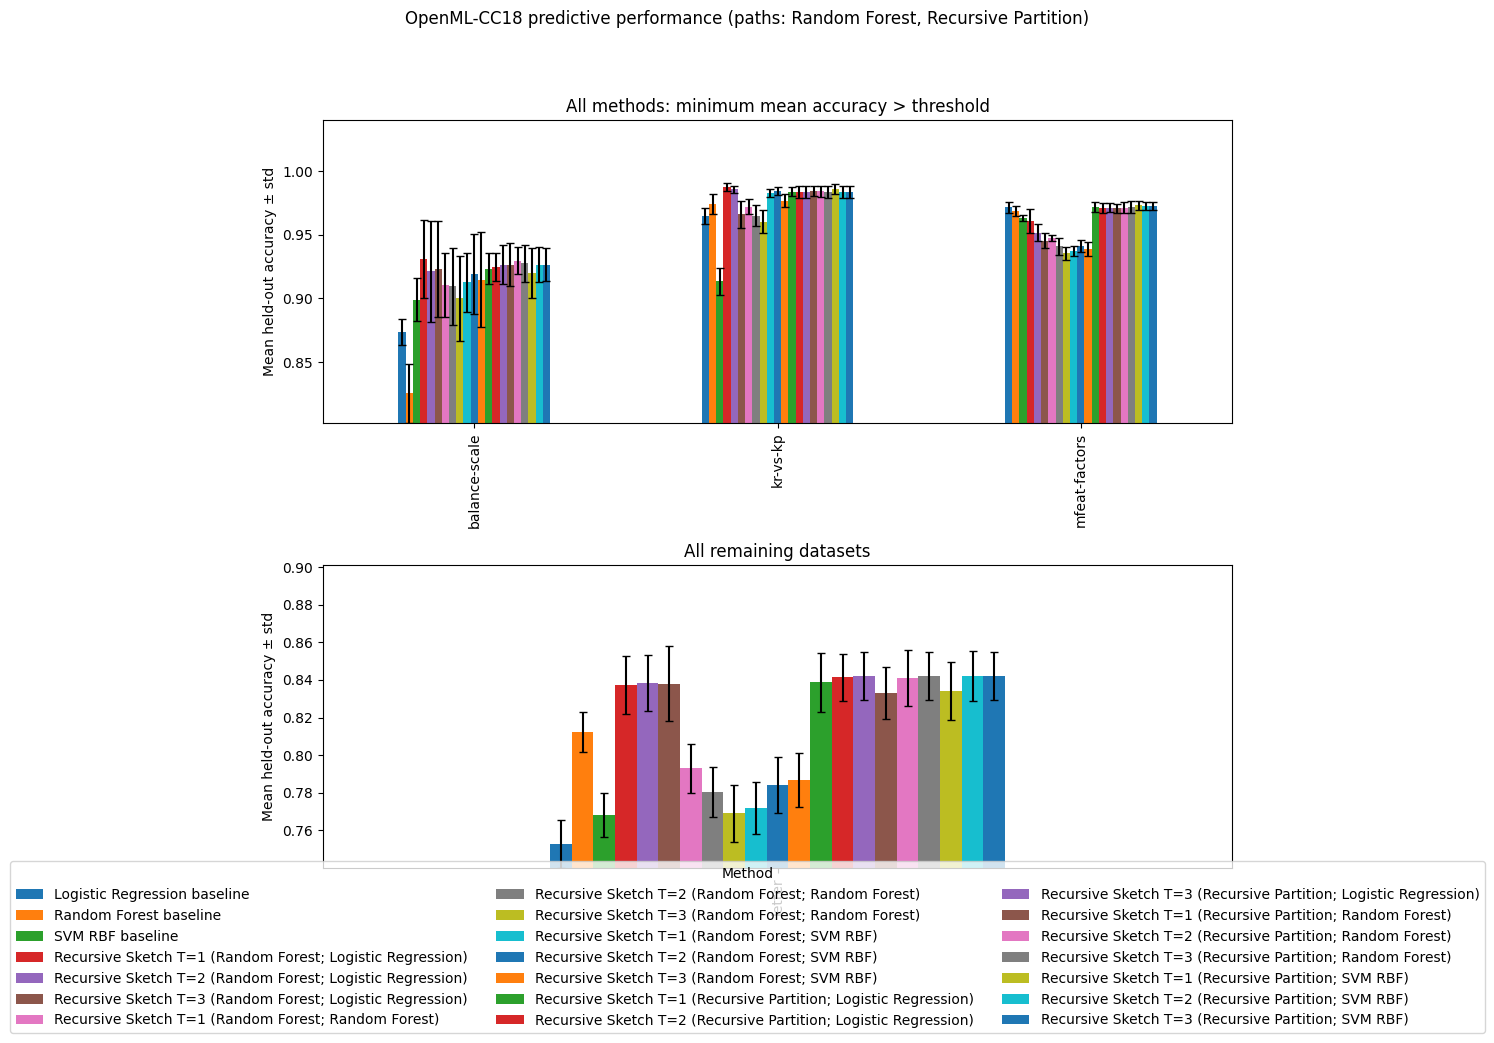

In [3]:
summary = results.groupby(['dataset', 'method'], as_index=False).agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
)
display(summary)

ACCURACY_THRESHOLD = 0.8
dataset_min_accuracy = summary.groupby('dataset')['mean_accuracy'].min()
dataset_order = summary['dataset'].drop_duplicates().tolist()
high_accuracy_datasets = [
    dataset for dataset in dataset_order
    if dataset_min_accuracy[dataset] > ACCURACY_THRESHOLD
]
low_accuracy_datasets = [
    dataset for dataset in dataset_order
    if dataset_min_accuracy[dataset] <= ACCURACY_THRESHOLD
]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
panel_specs = [
    ('All methods: minimum mean accuracy > threshold', high_accuracy_datasets),
    ('All remaining datasets', low_accuracy_datasets),
]
legend_handles, legend_labels = [], []
for ax, (panel_title, datasets) in zip(axes, panel_specs):
    ax.set_title(panel_title)
    if not datasets:
        ax.text(0.5, 0.5, 'No datasets', ha='center', va='center')
        ax.set_xticks([])
        continue
    panel_summary = summary[summary['dataset'].isin(datasets)]
    means = panel_summary.pivot(
        index='dataset', columns='method', values='mean_accuracy'
    ).reindex(index=datasets, columns=METHODS)
    stds = panel_summary.pivot(
        index='dataset', columns='method', values='std_accuracy'
    ).reindex(index=datasets, columns=METHODS)
    means.plot(
        kind='bar', yerr=stds, capsize=3, ax=ax, legend=False
    )
    panel_y_min = (means - stds).min().min()
    ax.set_ylim(bottom=panel_y_min)
    if not legend_handles:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90)

axes[0].set_ylabel('Mean held-out accuracy ± std')
axes[1].set_ylabel('Mean held-out accuracy ± std')
fig.legend(
    legend_handles, legend_labels, title='Method', loc='lower center',
    bbox_to_anchor=(0.5, -0.01), ncol=min(3, len(METHODS))
)
fig.suptitle(
    f'OpenML-CC18 predictive performance (paths: {", ".join(PATH_ESTIMATOR_LABELS[path_estimator] for path_estimator in PATH_ESTIMATORS)})',
    y=1.02,
)
fig.tight_layout(rect=(0, 0.10, 1, 0.98))


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['blocks']"

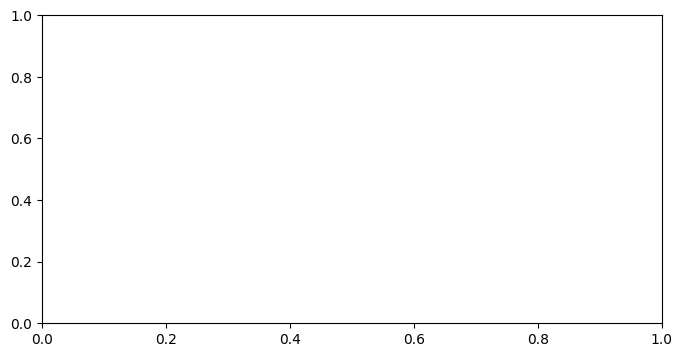

In [4]:
plot_critical_difference(
    results,
    block_column=['dataset_id', 'repetition_id'],
    method_column='method',
    score_column='accuracy',
    title=(
        'Critical differences over dataset × repetition blocks '
        f'(paths: {", ".join(PATH_ESTIMATOR_LABELS[path_estimator] for path_estimator in PATH_ESTIMATORS)})'
    ),
)

paired = results.pivot(
    index=['dataset_id', 'repetition_id'],
    columns='method',
    values='accuracy',
)
overall_gain_rows = []
per_dataset_gain_rows = []
for path_estimator in PATH_ESTIMATORS:
    for classifier in CLASSIFIERS:
        baseline_method = f'{CLASSIFIER_LABELS[classifier]} baseline'
        reference = paired[baseline_method]
        for iterations in ITERATIONS:
            method = f'Recursive Sketch T={iterations} ({PATH_ESTIMATOR_LABELS[path_estimator]}; {CLASSIFIER_LABELS[classifier]})'
            gain = paired[method] - reference
            half_width = t.ppf(0.975, len(gain) - 1) * gain.std(ddof=1) / np.sqrt(len(gain))
            overall_gain_rows.append({
                'method': method,
                'reference': baseline_method,
                'path_estimator': path_estimator,
                'mean_gain': gain.mean(),
                'ci_low': gain.mean() - half_width,
                'ci_high': gain.mean() + half_width,
                'n_blocks': len(gain),
            })
            dataset_stats = gain.groupby(level=0).agg(['mean', 'std'])
            for dataset_id, stats in dataset_stats.iterrows():
                per_dataset_gain_rows.append({
                    'dataset_id': dataset_id,
                    'method': method,
                    'reference': baseline_method,
                    'path_estimator': path_estimator,
                    'mean_gain': stats['mean'],
                    'std_gain': stats['std'],
                })

overall_gain_summary = pd.DataFrame(overall_gain_rows)
per_dataset_gain_summary = pd.DataFrame(per_dataset_gain_rows)
display(overall_gain_summary.style.format({
    'mean_gain': '{:+.3f}',
    'ci_low': '{:+.3f}',
    'ci_high': '{:+.3f}',
}))
display(per_dataset_gain_summary.style.format({
    'mean_gain': '{:+.3f}',
    'std_gain': '{:.3f}',
}))

The primary evidence is the CD diagram and the paired gain of each Recursive Sketch iteration relative to the matching raw-input baseline classifier. A positive overall gain is not sufficient for a cross-dataset claim if it is driven by one dataset; the per-dataset paired gains should be reported as well.